# Experiment 2 - Error Statistics


## Setup


In [28]:
# Setup for the Notebook

import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import os
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter, NullLocator, FixedLocator
from matplotlib.colors import Normalize
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq, least_squares
from scipy.stats import vonmises

# GP framework
from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes
from core.decoder.ml_decoder import decode

# All circular metrics -- including the per-trial decoder error -- come
# from the central metrics module (single source of truth). Only
# run_multiloc_trials (the trial engine) stays in core.population.
from core.population import run_multiloc_trials
from core.metrics import (
    circular_error,
    circular_variance_fisher,
    circular_kurtosis_fisher,
    circular_moments,
    vonmises_kde,
    _direct_circular_variance,
    _kde_circular_variance,
)

# Bays cache loader — single source of truth for the comparison reference
from experiments.bays_cache import load_bays_cache, list_available_caches

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [29]:
# === Notebook configuration ===
# Bays generating params come FROM the cache meta (no separate shared-constants
# file). We load the fixed M=100 reference using the loader's canonical
# defaults, then read the parameters off its metadata.

M_BAYS_REF = 100
bays_errors, bays_meta = load_bays_cache(M=M_BAYS_REF)   # loader defaults -> canonical cache

OMEGA_BAYS       = bays_meta['omega']
GAMMA_TOTAL_BAYS = bays_meta['gamma_total']
T_D              = bays_meta['T_d']
SEED             = bays_meta['seed']
SET_SIZES        = list(bays_meta['set_sizes'])
LAMBDA_BASE      = np.sqrt(OMEGA_BAYS)      # M-independent

# --- Genuine notebook-side config (NOT stored in the cache) ---
N_THETA        = 128
SIGMA_SQ       = 1e-6
N_BINS         = 50
KAPPA_BAYS_AC  = 80.0     # von Mises KDE smoothing for the Bays reference curves

print('=== Notebook config (Bays params read from cache meta) ===')
print(f'  reference cache = {bays_meta["cache_filename"]}  (fixed M={M_BAYS_REF})')
print(f'  omega={OMEGA_BAYS}  gamma_total={GAMMA_TOTAL_BAYS} Hz  T_d={T_D}s  seed={SEED}')
print(f'  set sizes = {SET_SIZES}')


=== Notebook config (Bays params read from cache meta) ===
  reference cache = bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz  (fixed M=100)
  omega=0.52  gamma_total=119.0 Hz  T_d=0.1s  seed=12345
  set sizes = [1, 2, 3, 4, 5, 6, 7, 8]


## Experiment Control

Single source of truth for the whole notebook. Three knobs drive every
downstream cell:

- **`M`** - population size (100 / 1000 / 10000). Need not match the Bays
  reference (fixed M=100); the error distribution of the homogeneous Bays
  model is invariant to neuron count, so we fit an M-neuron model to the
  fixed M=100 cache.
- **`DISTRIBUTION`** - how tuning *width* is sampled across locations:
  `'folded_normal'`, `'gamma'`, or `'sparse_sharp'`.
- **`MODEL`** - the generative tuning model: `'gp'` (Gaussian Process),
  `'vm'` (Von Mises with widths drawn from `DISTRIBUTION`), or `'bays'`
  (homogeneous Bays 2014 Eq. 1). All three are built by
  `generate_neuron_population` in `core.encoder.gaussian_process`.


In [30]:
# === EXPERIMENT CONTROL (the only M / DISTRIBUTION / MODEL knob) ===
M            = 10                 # GP/VM/Bays population size
DISTRIBUTION = 'gamma'     # 'folded_normal' | 'gamma' | 'sparse_sharp'
MODEL        = 'gp'                # 'gp' | 'vm' | 'bays'

# sparse_sharp knobs (ignored unless DISTRIBUTION == 'sparse_sharp')
N_HIGH          = 1
HIGH_MULTIPLIER = 3.0

# Amplitude variability (kept 0 to match the homogeneous Bays model)
GAIN_VARIABILITY = 0.0

assert DISTRIBUTION in ('folded_normal', 'gamma', 'sparse_sharp'), DISTRIBUTION
assert MODEL in ('gp', 'vm', 'bays'), MODEL

# --- ONE shared output directory for this run ---
#   result_data / experiment_2 / <date> / <distribution>_<size>_<model> / <timestamp>
EXPERIMENT_TAG = 'experiment_2'
_date = datetime.datetime.now().strftime('%Y%m%d')
_time = datetime.datetime.now().strftime('%H%M%S')
RESULT_BASE = Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
OUTPUT_DIR  = (RESULT_BASE / EXPERIMENT_TAG / _date /
               f'{DISTRIBUTION}_{M}_{MODEL}' / _time)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=== Experiment control (global) ===')
print(f'  M            = {M}')
print(f'  DISTRIBUTION = {DISTRIBUTION!r}')
print(f'  MODEL        = {MODEL!r}')
if DISTRIBUTION == 'sparse_sharp':
    print(f'  N_HIGH={N_HIGH}  HIGH_MULTIPLIER={HIGH_MULTIPLIER}')
print(f'  gamma per neuron (target) = GAMMA_TOTAL_BAYS / M = {GAMMA_TOTAL_BAYS / M:.4f} Hz')
print(f'  Bays reference = fixed M={M_BAYS_REF} (decoupled from model M)')
print(f'  OUTPUT_DIR   = {OUTPUT_DIR}')


=== Experiment control (global) ===
  M            = 10
  DISTRIBUTION = 'gamma'
  MODEL        = 'gp'
  gamma per neuron (target) = GAMMA_TOTAL_BAYS / M = 11.9000 Hz
  Bays reference = fixed M=100 (decoupled from model M)
  OUTPUT_DIR   = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_2/20260803/gamma_10_gp/201034


## Model Framework

Tuning-curve generation lives in `core.encoder.gaussian_process`
(`generate_neuron_population`, which now dispatches on `model` for GP / VM /
Bays), and the vectorised continuous-theta trial engine lives in
`core.population` (`run_multiloc_trials`, imported above). The notebook only
assembles arguments and orchestrates the fit - it does not reimplement
generation or the trial loop.

The single dispatcher below turns the fit's free *width* parameter into a
population under the chosen `MODEL` and returns `(thetas, f_all)` ready for
`run_multiloc_trials`.


In [31]:
# === Population dispatcher: one place that assembles generation args ===
# `width` is the fit's free width parameter, interpreted per MODEL:
#   MODEL='gp'            -> width is the GP base lengthscale (lambda)
#   MODEL in ('vm','bays') -> width is the Von Mises width (omega)
# f_all is a list over locations, each (M, n_theta), for run_multiloc_trials.
def build_population(width, sigma, seed):
    max_locs = max(SET_SIZES)
    kw = dict(
        n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=width, lengthscale_variability=sigma,
        seed=seed, gain_variability=GAIN_VARIABILITY, model=MODEL,
    )
    if MODEL in ('gp', 'vm'):
        kw['method'] = DISTRIBUTION
        if DISTRIBUTION == 'sparse_sharp':
            kw.update(n_high=N_HIGH, high_multiplier=HIGH_MULTIPLIER)
    if MODEL in ('vm', 'bays'):
        kw['omega'] = width          # width is omega for VM / Bays
    population = generate_neuron_population(**kw)
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(max_locs)]
    return thetas, f_all


## Model to Bays Parameters Fit

Fits the tuning model (`width`, `gamma`, `sigma`) to the cached Bays errors,
using the global `M` / `DISTRIBUTION` / `MODEL`. The model has `M` neurons and
is fit to the fixed **M=100** Bays reference. The optimisation is identical
across samplers and models - only the forward model differs.


In [32]:
# === Model to Bays Parameters Fit - bind to the global control ===
# Uses the single global M / DISTRIBUTION (control cell in Setup). Fits the GP
# (M neurons) to the FIXED M=100 Bays reference loaded in the config cell.
FIT_OUTPUT_DIR = OUTPUT_DIR
fit_bays_errors, fit_bays_meta = bays_errors, bays_meta   # the fixed M=100 reference

print('=== Model to Bays Parameters Fit ===')
print(f'  M              = {M}')
print(f'  MODEL          = {MODEL!r}')
print(f'  DISTRIBUTION   = {DISTRIBUTION!r}')
if DISTRIBUTION == 'sparse_sharp':
    print(f'  N_HIGH={N_HIGH}  HIGH_MULTIPLIER={HIGH_MULTIPLIER}')
print(f'  Bays reference = {fit_bays_meta["cache_filename"]}  (fixed M={M_BAYS_REF})')


=== Model to Bays Parameters Fit ===
  M              = 10
  MODEL          = 'gp'
  DISTRIBUTION   = 'gamma'
  Bays reference = bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz  (fixed M=100)


In [33]:
# === Fit configuration: optimizer setup driven by the global Experiment Control ===

# --- Restrict THIS notebook to the classic Bays set sizes -------------------
# The reference cache now carries all of 1..8 (other experiments need them),
# but figure 2 only uses the original 1, 2, 4, 8. Pin SET_SIZES here so the
# fit target, the fit, and the overlay figure all use the same four sizes.
SET_SIZES = [1, 2, 4, 8]

N_DATA       = 10000   # MUST equal the cache's trial count
N_TRIALS_FIT = 1000    # GP forward-model trials per evaluation
SEED_FIT     = SEED    # anchor for fit-side seeds

# Histogram grid for the residual
N_BINS_FIT  = 50
BIN_EDGES   = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# Starting points and bounds depend on the chosen sampler. Gamma requires
# CV strictly > 0 (undefined at CV=0); folded-Normal allows sigma=0 cleanly.
if DISTRIBUTION == 'folded_normal':
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_TARGET = 0.0     # Bays is homogeneous; we expect sigma -> 0
    SIGMA_NAME   = 'sigma_lambda'
else:  # 'gamma' or 'sparse_sharp' (both use a strictly-positive CV-like knob)
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.01]
    HI = [3.0, 10.0, 10.0]
    SIGMA_TARGET = 0.01    # near the lower bound; Bays is homogeneous
    SIGMA_NAME   = 'cv'

DIFF_STEP = 0.05

# Recovery targets
LAMBDA_TARGET = np.sqrt(OMEGA_BAYS) if MODEL == 'gp' else OMEGA_BAYS
GAMMA_TARGET  = GAMMA_TOTAL_BAYS / M

print(f'Optimizer configuration  (M={M}, model={MODEL}, distribution={DISTRIBUTION}):')
print(f'  x0     = {X0}  (lambda, gamma, {SIGMA_NAME})')
print(f'  bounds = ({LO}, {HI})')
print(f'  set sizes (figure 2) = {SET_SIZES}')
print(f'  Recovery targets: lambda={LAMBDA_TARGET:.4f}, '
      f'gamma={GAMMA_TARGET:.4f}, {SIGMA_NAME}=~{SIGMA_TARGET}')

# Build the fit-target vector from the cached Bays errors.
# Subset to the four figure-2 sizes; the cache dict still holds all of 1..8.
data_errors = {N: fit_bays_errors[N] for N in SET_SIZES}
data_hists  = {}
for N in SET_SIZES:
    h, _ = np.histogram(data_errors[N], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])
print(f'  Data vector shape: {data_vector.shape}')

Optimizer configuration  (M=10, model=gp, distribution=gamma):
  x0     = [1.0, 2.0, 0.5]  (lambda, gamma, cv)
  bounds = ([0.1, 0.1, 0.01], [3.0, 10.0, 10.0])
  set sizes (figure 2) = [1, 2, 4, 8]
  Recovery targets: lambda=0.7211, gamma=11.9000, cv=~0.01
  Data vector shape: (200,)


In [34]:
# === Unified fit: dispatches on MODEL / DISTRIBUTION via build_population ===
# Same procedure (least_squares on histogram residuals) for every model;
# the forward model and per-trial engine come from the modules.

# build_population depends on (width, sigma) but NOT on gamma, so the gamma
# finite-difference column of the Jacobian would otherwise rebuild an
# identical population every step. Cache on (width, sigma, seed). Cleared on
# each (re)run of this cell so a change of MODEL / DISTRIBUTION can never
# reuse a stale population.
_pop_cache = {}
def _cached_population(width, sigma, seed):
    key = (float(width), float(sigma), int(seed))
    pop = _pop_cache.get(key)
    if pop is None:
        pop = build_population(width, sigma, seed)
        _pop_cache[key] = pop
    return pop

def model_forward(width, gamma_per_neuron, sigma, seed=0):
    """Build a population and run the trial engine, returning a histogram
    vector concatenated across set sizes."""
    thetas, f_all = _cached_population(width, sigma, seed)
    pred_hists = []
    for N in SET_SIZES:
        rng = np.random.RandomState(seed + N)
        errs = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual(params):
    width, gam, sig = params
    return data_vector - model_forward(width, gam, sig, seed=SEED_FIT)


print(f'Running fit  (M={M}, model={MODEL}, distribution={DISTRIBUTION})...')
t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
)
print(f'Fit completed in {time.time()-t0:.1f}s')

# Unpack. omega_hat mapping is model-dependent: GP fits a lengthscale
# (omega = lambda**2); VM / Bays fit omega directly.
lambda_hat, gamma_hat, sigma_lambda_hat = result.x
omega_hat       = lambda_hat ** 2 if MODEL == 'gp' else lambda_hat
gamma_total_hat = gamma_hat * M
SIGMA_LAMBDA_TARGET = SIGMA_TARGET   # alias for the plot cell that follows

print(f'\n=== {MODEL.upper()} / {DISTRIBUTION} fit results ===')
print(f'  width_hat        = {lambda_hat:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {gamma_hat:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  {SIGMA_NAME}_hat = {sigma_lambda_hat:.4f}    (target ~ {SIGMA_TARGET})')
print(f'  -> omega_hat     = {omega_hat:.4f}    (Bays {OMEGA_BAYS})')
print(f'  -> gamma_total   = {gamma_total_hat:.1f} Hz  (Bays {GAMMA_TOTAL_BAYS})')
print(f'  cost             = {result.cost:.6f}')

# Build the fitted population ONCE, then reuse it for both the plotted
# predictions and the large-sample metric pool below.
thetas_fit, f_all_fit = build_population(lambda_hat, sigma_lambda_hat, SEED_FIT)

fitted_errors = {}
fitted_hists  = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 7000 + N)
    errs = run_multiloc_trials(
        f_all_fit, thetas_fit, tuple(range(N)), 0,
        gamma_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    fitted_errors[N] = errs
    h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
    fitted_hists[N] = h
    m = circular_moments(errs)
    print(f'  fitted N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

# --- Large-sample pool ONLY for the plotted summary metrics -------------
# Fisher circular kurtosis divides by (1 - rho1)^2, which is near-singular
# for the concentrated errors the high-CV regime produces. Estimating the
# plotted moments on a larger pool stabilises the point estimate WITHOUT
# touching the population, the CV, or the fit. Reuses f_all_fit.
N_TRIALS_METRIC = 50000
metric_errors = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 90000 + N)
    metric_errors[N] = run_multiloc_trials(
        f_all_fit, thetas_fit, tuple(range(N)), 0,
        gamma_hat, T_D, SIGMA_SQ, N_TRIALS_METRIC, rng)
    _m = circular_moments(metric_errors[N])
    _rho1 = float(np.abs(np.mean(np.exp(1j * metric_errors[N]))))
    print(f'  metric  N={N}: var={_m["variance"]:.4f}  '
          f'kurt={_m["kurtosis"]:.3f}  rho1={_rho1:.4f}  (n={N_TRIALS_METRIC})')


Running fit  (M=10, model=gp, distribution=gamma)...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.3177e+00                                    2.67e+02    
       1              3         3.9865e+00      1.33e+00       3.14e-02       1.35e+01    
       2             15         3.9865e+00      0.00e+00       0.00e+00       1.35e+01    
`xtol` termination condition is satisfied.
Function evaluations 15, initial cost 5.3177e+00, final cost 3.9865e+00, first-order optimality 1.35e+01.
Fit completed in 2.3s

=== GP / gamma fit results ===
  width_hat        = 0.9977   (target 0.7211)
  gamma_hat        = 2.0180    (target 11.9000)
  cv_hat = 0.5256    (target ~ 0.01)
  -> omega_hat     = 0.9953    (Bays 0.52)
  -> gamma_total   = 20.2 Hz  (Bays 119.0)
  cost             = 3.986507
  fitted N=1: var=1.6982  kurt=0.661
  fitted N=2: var=1.8533  kurt=0.478
  fitted N=4: var=2.3434  kurt=0.256
  fitted N=8: var=4.04

In [35]:
# === Log this fit to an accumulating CSV (one row per fit, tagged by UUID) ===
# Column order: identifiers -> model parameters -> parameters used for THIS
# fit (inputs) -> fitted hats (outputs). Inputs are deliberately recorded
# before the hats. Appends to a single master log that accumulates across every
# run and config; a fresh UUID is minted on each execution of this cell.
import csv
import uuid

FIT_LOG_PATH = RESULT_BASE / EXPERIMENT_TAG / 'fit_log.csv'
FIT_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

fit_record = {
    # --- identifiers ---
    'uuid':             str(uuid.uuid4()),
    'datetime':         datetime.datetime.now().isoformat(timespec='seconds'),

    # --- model parameters (population / config knobs) ---
    'model':            MODEL,
    'M':                int(M),
    'distribution':     DISTRIBUTION,
    'n_high':           int(N_HIGH),
    'high_multiplier':  float(HIGH_MULTIPLIER),
    'gain_variability': float(GAIN_VARIABILITY),

    # --- parameters used for THIS fit (inputs; recorded BEFORE the hats) ---
    'bays_cache':       bays_meta['cache_filename'],
    'omega_bays':       float(OMEGA_BAYS),
    'gamma_total_bays': float(GAMMA_TOTAL_BAYS),
    'T_d':              float(T_D),
    'sigma_sq':         float(SIGMA_SQ),
    'set_sizes':        repr(list(SET_SIZES)),
    'n_trials_fit':     int(N_TRIALS_FIT),
    'n_bins_fit':       int(N_BINS_FIT),
    'seed_fit':         int(SEED_FIT),
    'diff_step':        float(DIFF_STEP),
    'x0':               repr([float(v) for v in X0]),
    'lower_bounds':     repr([float(v) for v in LO]),
    'upper_bounds':     repr([float(v) for v in HI]),
    'sigma_name':       SIGMA_NAME,
    'lambda_target':    float(LAMBDA_TARGET),
    'gamma_target':     float(GAMMA_TARGET),
    'sigma_target':     float(SIGMA_TARGET),

    # --- fitted hats (outputs) ---
    'lambda_hat':       float(lambda_hat),
    'gamma_hat':        float(gamma_hat),
    'sigma_hat':        float(sigma_lambda_hat),
    'omega_hat':        float(omega_hat),
    'gamma_total_hat':  float(gamma_total_hat),
    'cost':             float(result.cost),
    'nfev':             int(result.nfev),
    'status':           int(result.status),
    'success':          bool(result.success),
}
fieldnames = list(fit_record.keys())

# Guard: never silently append under a mismatched schema. If an existing log
# has different columns (e.g. an older code version), write this row to a
# fresh timestamped file instead of corrupting the master log.
target_path = FIT_LOG_PATH
if FIT_LOG_PATH.exists() and FIT_LOG_PATH.stat().st_size > 0:
    with open(FIT_LOG_PATH, newline='') as f:
        existing_header = next(csv.reader(f), [])
    if existing_header != fieldnames:
        stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        target_path = FIT_LOG_PATH.with_name(f'fit_log_{stamp}.csv')
        print(f'WARNING: {FIT_LOG_PATH.name} has a different schema; '
              f'writing to {target_path.name} instead of corrupting the master.')

write_header = not (target_path.exists() and target_path.stat().st_size > 0)
with open(target_path, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if write_header:
        writer.writeheader()
    writer.writerow(fit_record)

n_rows = sum(1 for _ in open(target_path)) - 1
print(f'Logged fit {fit_record["uuid"]}')
print(f'  -> {target_path}  ({n_rows} record(s) total)')
print(f'  model  : model={MODEL} M={M} distribution={DISTRIBUTION}')
print(f'  inputs : omega_bays={OMEGA_BAYS} gamma_total_bays={GAMMA_TOTAL_BAYS} '
      f'n_trials_fit={N_TRIALS_FIT} seed_fit={SEED_FIT} set_sizes={list(SET_SIZES)}')
print(f'  hats   : lambda_hat={lambda_hat:.4f} gamma_hat={gamma_hat:.4f} '
      f'{SIGMA_NAME}_hat={sigma_lambda_hat:.4f} omega_hat={omega_hat:.4f} '
      f'gamma_total_hat={gamma_total_hat:.1f} cost={result.cost:.6f}')


Logged fit 25b8dd09-fa16-4acb-b325-fdb45c54a56d
  -> /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_2/fit_log.csv  (5 record(s) total)
  model  : model=gp M=10 distribution=gamma
  inputs : omega_bays=0.52 gamma_total_bays=119.0 n_trials_fit=1000 seed_fit=12345 set_sizes=[1, 2, 4, 8]
  hats   : lambda_hat=0.9977 gamma_hat=2.0180 cv_hat=0.5256 omega_hat=0.9953 gamma_total_hat=20.2 cost=3.986507


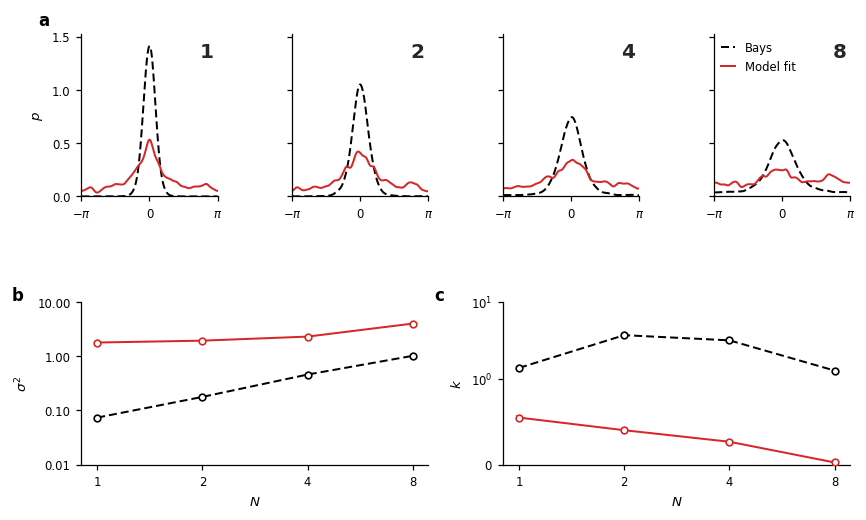

In [36]:
# === Plot: fitted model (red) vs Bays-generated data (black, dashed) ===
# Panel c (kurtosis) now:
#   * uses the large-sample metric pool (metric_errors) from cell 14,
#   * shows bootstrap 95% CIs so near-singular points read as uncertain,
#   * uses a symlog y-axis so negative / near-zero kurtosis stays visible
#     instead of being silently dropped by a log axis,
#   * marks points where rho1 > 0.99 (estimator near its 1/(1-rho1)^2
#     singularity) with a solid fill.
# Panel b (variance, always positive) keeps the original log axis.

import matplotlib as mpl
from matplotlib.ticker import (
    ScalarFormatter, NullLocator, FixedLocator, MaxNLocator, LogLocator,
)

NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference

theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)

KDE_YTICKS = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]

# Fall back to the fit-sized pool if cell 14's large pool wasn't (re)run.
metric_errors = globals().get('metric_errors', fitted_errors)


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Symmetric-in-log padding around the actual data range (positive only)."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return 0.01, 10.0
    lo_exp = np.floor(np.log10(v.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(v.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp


def _auto_log_y(ax, lo, hi, numticks=4):
    """Decade major ticks across [lo, hi]; labelled, no minor ticks."""
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=numticks))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


def _kurt_ci(errors, n_boot=200, seed=0):
    """Fisher circular kurtosis with a bootstrap 95% CI and rho1.

    rho1 (mean resultant length) is returned as a conditioning flag: as
    rho1 -> 1 the estimator's 1/(1-rho1)^2 factor makes it fragile.
    """
    errors = np.asarray(errors, dtype=float)
    rng = np.random.RandomState(seed)
    n = len(errors)
    k = circular_kurtosis_fisher(errors)
    boots = np.array([circular_kurtosis_fisher(errors[rng.randint(0, n, n)])
                      for _ in range(n_boot)])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    rho1 = float(np.abs(np.mean(np.exp(1j * errors))))
    return k, lo, hi, rho1


# Panel that carries the legend: the set-size-8 KDE panel (fallback: last).
LEGEND_IDX = SET_SIZES.index(8) if 8 in SET_SIZES else len(SET_SIZES) - 1


with mpl.rc_context(NATURE_STYLE):
    # ---- Geometry (panel layout matched to the CV-sweep figure) ----
    fig = plt.figure(figsize=(7.2, 4.6))
    gs = gridspec.GridSpec(
        2, len(SET_SIZES),
        hspace=0.65, wspace=0.55,
        left=0.08, right=0.97, bottom=0.12, top=0.90,
    )
    # (Title removed.)

    # ---- precompute KDEs ----
    kdes_data = {N: vonmises_kde(data_errors[N],   theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}
    kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}

    peak = max(max(k.max() for k in kdes_data.values()),
               max(k.max() for k in kdes_fit.values()))
    kde_ymax   = peak * 1.08
    kde_yticks = _pick_kde_yticks(kde_ymax)

    # ---- Row 1: KDE overlays ----
    for i, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs[0, i])
        # Labels now attach to the legend panel (set size 8) so the legend
        # can live there instead of on the first panel.
        ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                linestyle=BAYS_LINESTYLE,
                label='Bays' if i == LEGEND_IDX else None)
        ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                label='Model fit' if i == LEGEND_IDX else None)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax.set_yticks(kde_yticks)
        ax.set_ylim(0, kde_ymax)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())

        ax.text(0.97, 0.95, f'{N}', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='right',
                color='0.15')

        if i == 0:
            ax.set_ylabel(r'$p$')
            ax.text(-0.32, 1.14, 'a', transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)

        # Legend now on the set-size-8 panel (upper-left, clear of the '8').
        if i == LEGEND_IDX:
            ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                      borderaxespad=0.2)

        _style_axes(ax)

    # ---- Row 2: variance and kurtosis vs set size ----
    # Bays reference moments from its own error pool (unchanged).
    var_bays  = np.array([circular_moments(data_errors[N])['variance'] for N in SET_SIZES])
    kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis'] for N in SET_SIZES])
    # GP moments now from the LARGE metric pool (stable estimates).
    var_fit   = np.array([circular_moments(metric_errors[N])['variance'] for N in SET_SIZES])
    kf, klo, khi, krho = map(
        np.array,
        zip(*[_kurt_ci(metric_errors[N], seed=N) for N in SET_SIZES]))

    # ---- Panel b: variance (log axis; variance is strictly positive) ----
    ax_var = fig.add_subplot(gs[1, :2])
    ax_var.plot(SET_SIZES, var_bays, marker='o', color=BAYS_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, *_data_driven_log_ylim(np.concatenate([var_bays, var_fit])),
                numticks=4)
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.text(-0.20, 1.10, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    # ---- Panel c: kurtosis (symlog; CIs; singularity flag) ----
    ax_kurt = fig.add_subplot(gs[1, 2:])
    # (Gray y=0 reference line removed; x-axis now sits at 0.)
    ax_kurt.plot(SET_SIZES, kurt_bays, marker='o', color=BAYS_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_kurt.errorbar(SET_SIZES, kf, yerr=np.vstack([kf - klo, khi - kf]),
                     marker='o', color=GP_COLOR, lw=1.2, ms=4, mfc='white',
                     mew=1.0, capsize=2, zorder=4)
    # Solid-fill the points where the estimator is near its singularity.
    frag = krho > 0.99
    if frag.any():
        ax_kurt.plot(np.array(SET_SIZES)[frag], kf[frag], 'o',
                     color=GP_COLOR, ms=4, zorder=5)

    ax_kurt.set_yscale('symlog', linthresh=1.0)   # linear in [-1,1], log beyond
    _setsize_log_axis(ax_kurt, SET_SIZES)
    _ymax = np.nanmax(np.concatenate([khi, kurt_bays, kf])) * 2.0
    ax_kurt.set_ylim(0.0, max(_ymax, 10.0))       # x-axis at the 0 line
    ax_kurt.yaxis.set_minor_locator(NullLocator())
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.20, 1.10, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    fig.savefig(FIT_OUTPUT_DIR / 'fit_overlay.png',
                dpi=300, bbox_inches='tight')
    fig.savefig(FIT_OUTPUT_DIR / 'fit_overlay.pdf',
                bbox_inches='tight')
    plt.show()

## Fixed-CV Sweep

At each CV in `CV_VALUES`, fits only (`width`, `gamma`) with the width CV held
fixed in the forward model - one fit per CV value - so we see how recovery
quality varies with imposed width heterogeneity. Uses the same global
`M` / `DISTRIBUTION` / `MODEL` and the same fixed **M=100** Bays reference.


In [37]:
# === Fixed-CV Sweep - bind to the global control ===
SWEEP_OUTPUT_DIR = OUTPUT_DIR
sweep_bays_errors, sweep_bays_meta = bays_errors, bays_meta   # fixed M=100 reference

# CV values to sweep (log-spaced from near-homogeneous to heterogeneous).
CV_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# Figure filename / title tag for this run (folder already carries date+time).
SWEEP_TAG = f'M{M}_{DISTRIBUTION}_{MODEL}'

print('=== Fixed-CV Sweep ===')
print(f'  M            = {M}')
print(f'  DISTRIBUTION = {DISTRIBUTION!r}')
print(f'  MODEL        = {MODEL!r}')
print(f'  CV values    = {CV_VALUES}')
print(f'  tag          = {SWEEP_TAG}')
print(f'  Bays ref     = {sweep_bays_meta["cache_filename"]}  (fixed M={M_BAYS_REF})')


=== Fixed-CV Sweep ===
  M            = 10
  DISTRIBUTION = 'gamma'
  MODEL        = 'gp'
  CV values    = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  tag          = M10_gamma_gp
  Bays ref     = bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz  (fixed M=100)


In [38]:
# === Fixed-CV sweep: one (width, gamma) fit per CV value ===
# Two-parameter fit at each fixed CV; same optimiser as the main fit, only
# the forward model has the width CV pinned.

# Figure 2 sweeps only the classic Bays sizes; the cache holds 1..8.
SET_SIZES = [1, 2, 4, 8]
sweep_bays_errors = {N: sweep_bays_errors[N] for N in SET_SIZES}

N_TRIALS_FIT     = 1000
SEED_FIT         = SEED
N_BINS_FIT       = 50
BIN_EDGES        = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)

sweep_data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(sweep_bays_errors[N], bins=BIN_EDGES, density=True)
    sweep_data_hists[N] = h
sweep_data_vector = np.concatenate([sweep_data_hists[N] for N in SET_SIZES])

# Same (width, sigma)-keyed population cache as the main fit: within a fixed
# CV only width varies during a fit, so the gamma column reuses the build.
_pop_cache_sweep = {}
def _cached_population_sweep(width, sigma, seed):
    key = (float(width), float(sigma), int(seed))
    pop = _pop_cache_sweep.get(key)
    if pop is None:
        pop = build_population(width, sigma, seed)
        _pop_cache_sweep[key] = pop
    return pop

X0_FIXED  = [1.0, 2.0]
LO_FIXED  = [0.1, 0.1]
HI_FIXED  = [3.0, 10.0]
DIFF_STEP_FIXED = 0.05

print(f'Fixed-CV sweep  (M={M}, model={MODEL}, distribution={DISTRIBUTION}): '
      f'CV in {CV_VALUES}')
print(f'  set sizes (figure 2) = {SET_SIZES}')
print(f'  Per-CV fit: x0={X0_FIXED}, bounds=({LO_FIXED}, {HI_FIXED})')
print()


def make_residual(cv_fixed):
    def forward_fixed(width, gamma_per_neuron, seed=0):
        thetas, f_all = _cached_population_sweep(width, cv_fixed, seed)
        pred_hists = []
        for N in SET_SIZES:
            rng = np.random.RandomState(seed + N)
            errs = run_multiloc_trials(
                f_all, thetas, tuple(range(N)), 0,
                gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
            h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
            pred_hists.append(h)
        return np.concatenate(pred_hists)

    def residual_fn(params):
        width, gam = params
        return sweep_data_vector - forward_fixed(width, gam, seed=SEED_FIT)

    return residual_fn, forward_fixed


sweep_results = {}
for cv in CV_VALUES:
    print(f'\n--- CV = {cv} ---')
    t0 = time.time()
    residual_fn, forward_fn = make_residual(cv)
    result = least_squares(
        residual_fn, x0=X0_FIXED, bounds=(LO_FIXED, HI_FIXED),
        method='trf', diff_step=DIFF_STEP_FIXED, verbose=0,
    )
    lam_hat, gam_hat = result.x
    print(f'  width_hat = {lam_hat:.4f},  gamma_hat = {gam_hat:.4f},  '
          f'cost = {result.cost:.4f},  time = {time.time()-t0:.1f}s')

    thetas_fit, f_all_fit = build_population(lam_hat, cv, SEED_FIT)
    fitted_errors_per_cv = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 7000 + N)
        errs = run_multiloc_trials(
            f_all_fit, thetas_fit, tuple(range(N)), 0,
            gam_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        fitted_errors_per_cv[N] = errs
    sweep_results[cv] = {
        'lambda_hat':    lam_hat,
        'gamma_hat':     gam_hat,
        'omega_hat':     lam_hat ** 2 if MODEL == 'gp' else lam_hat,
        'gamma_total':   gam_hat * M,
        'cost':          result.cost,
        'fitted_errors': fitted_errors_per_cv,
    }

print('\n=== Sweep summary ===')
print(f'{"CV":>6}  {"width":>8}  {"gamma":>8}  {"omega":>8}  {"gamma_tot":>10}  {"cost":>8}')
for cv in CV_VALUES:
    r = sweep_results[cv]
    print(f'{cv:>6.2f}  {r["lambda_hat"]:>8.4f}  {r["gamma_hat"]:>8.4f}  '
          f'{r["omega_hat"]:>8.4f}  {r["gamma_total"]:>10.2f}  {r["cost"]:>8.4f}')

# Names the downstream summary cells expect.
bays_cached_errors = sweep_bays_errors
bays_errs = sweep_bays_errors


Fixed-CV sweep  (M=10, model=gp, distribution=gamma): CV in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  set sizes (figure 2) = [1, 2, 4, 8]
  Per-CV fit: x0=[1.0, 2.0], bounds=([0.1, 0.1], [3.0, 10.0])


--- CV = 0.1 ---
  width_hat = 1.0000,  gamma_hat = 2.0000,  cost = 4.1134,  time = 2.4s

--- CV = 0.5 ---
  width_hat = 0.9647,  gamma_hat = 2.2638,  cost = 3.9711,  time = 2.7s

--- CV = 1.0 ---
  width_hat = 1.1817,  gamma_hat = 2.0197,  cost = 5.2872,  time = 2.7s

--- CV = 2.0 ---
  width_hat = 1.0117,  gamma_hat = 2.0703,  cost = 6.2882,  time = 2.6s

--- CV = 5.0 ---
  width_hat = 1.0297,  gamma_hat = 2.1614,  cost = 5.9246,  time = 1.8s

--- CV = 10.0 ---
  width_hat = 1.0263,  gamma_hat = 2.0872,  cost = 5.5838,  time = 1.3s

=== Sweep summary ===
    CV     width     gamma     omega   gamma_tot      cost
  0.10    1.0000    2.0000    1.0000       20.00    4.1134
  0.50    0.9647    2.2638    0.9306       22.64    3.9711
  1.00    1.1817    2.0197    1.3965       20.20    5.2872
  2.00 

In [39]:
# === Part 2 — Bays reference arrays + shared, sweep-wide log y-ranges ===
# circular_moments returns variance AND kurtosis in one pass -> call it once
# per error set. Per-CV fitted moments are stored back onto sweep_results so
# the per-CV figure cell (Part 3) reuses them instead of recomputing.
_bays_moments = {N: circular_moments(bays_errs[N]) for N in SET_SIZES}
var_bays_arr  = np.array([_bays_moments[N]['variance'] for N in SET_SIZES])
kurt_bays_arr = np.array([_bays_moments[N]['kurtosis'] for N in SET_SIZES])

var_gp_all, kurt_gp_all = [], []
for cv in CV_VALUES:
    moments = {N: circular_moments(sweep_results[cv]['fitted_errors'][N])
               for N in SET_SIZES}
    sweep_results[cv]['moments'] = moments          # reused by the figure cell
    for N in SET_SIZES:
        var_gp_all.append(moments[N]['variance'])
        kurt_gp_all.append(moments[N]['kurtosis'])
var_gp_all  = np.array(var_gp_all)
kurt_gp_all = np.array(kurt_gp_all)

print('Data ranges across the sweep:')
print(f'  variance:  Bays in [{var_bays_arr.min():.4f}, {var_bays_arr.max():.4f}], '
      f'GP in [{var_gp_all.min():.4f}, {var_gp_all.max():.4f}]')
print(f'  kurtosis:  Bays in [{kurt_bays_arr.min():.4f}, {kurt_bays_arr.max():.4f}], '
      f'GP in [{kurt_gp_all.min():.4f}, {kurt_gp_all.max():.4f}]')
print()


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Decade-padded [lo, hi] bracketing the positive, finite data.

    Computed ONCE over the whole sweep so every figure shares the same
    non-clipping range. Non-positive values can't appear on a log axis;
    if any are present we report a count so they aren't silently dropped.
    """
    v = np.asarray(values, dtype=float)
    finite = v[np.isfinite(v)]
    n_neg = int(np.sum(finite <= 0))
    pos = finite[finite > 0]
    if pos.size == 0:
        return 0.01, 10.0, n_neg
    lo_exp = np.floor(np.log10(pos.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(pos.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp, n_neg


VAR_LO, VAR_HI, _var_neg = _data_driven_log_ylim(
    np.concatenate([var_bays_arr, var_gp_all]))
KURT_LO, KURT_HI, _kurt_neg = _data_driven_log_ylim(
    np.concatenate([kurt_bays_arr, kurt_gp_all]))

print(f'Shared variance y-range:  [{VAR_LO:g}, {VAR_HI:g}]')
print(f'Shared kurtosis y-range:  [{KURT_LO:g}, {KURT_HI:g}]')
if _kurt_neg:
    print(f'  WARNING: {_kurt_neg} kurtosis value(s) <= 0 cannot be shown on a '
          f'log axis. Consider a symlog scale if these matter.')
if _var_neg:
    print(f'  WARNING: {_var_neg} variance value(s) <= 0 (unexpected).')
print()

Data ranges across the sweep:
  variance:  Bays in [0.0734, 1.0153], GP in [1.6281, 8.1581]
  kurtosis:  Bays in [1.2862, 3.7087], GP in [-0.0405, 0.6034]

Shared variance y-range:  [0.01, 100]
Shared kurtosis y-range:  [0.001, 10]



Plotting per-CV figure for CV = 0.1


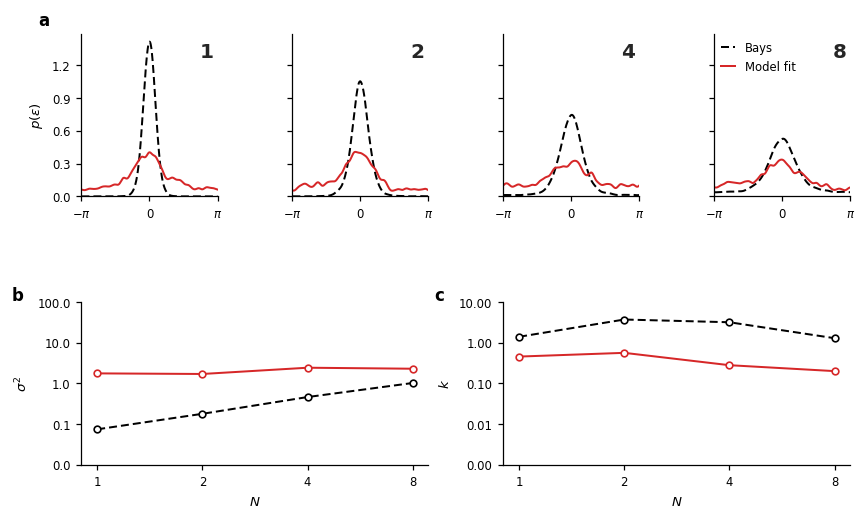

Plotting per-CV figure for CV = 0.5


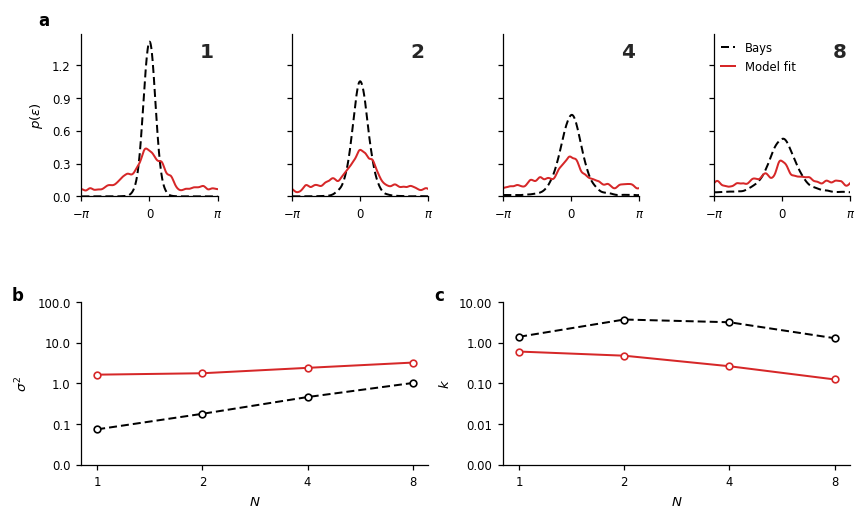

Plotting per-CV figure for CV = 1.0


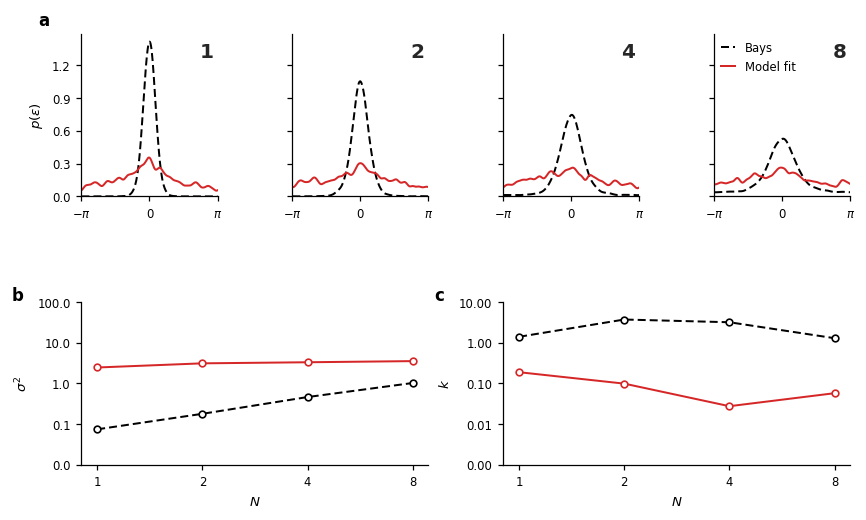

Plotting per-CV figure for CV = 2.0


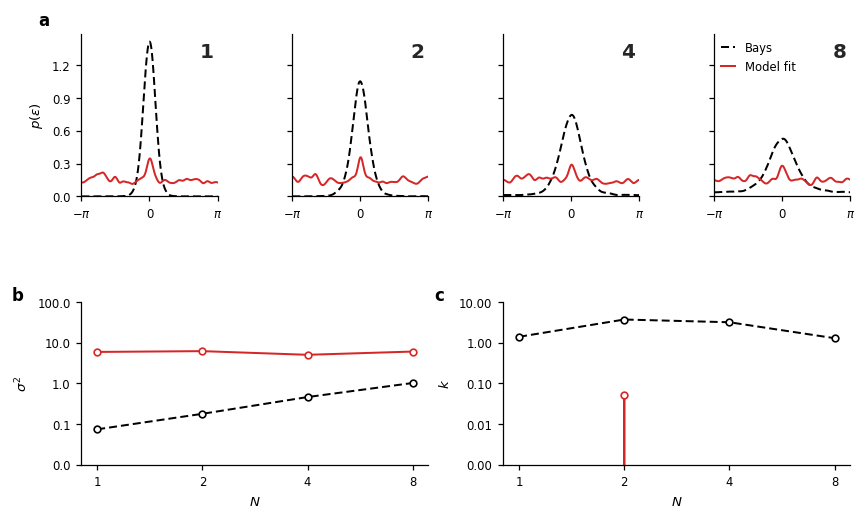

Plotting per-CV figure for CV = 5.0


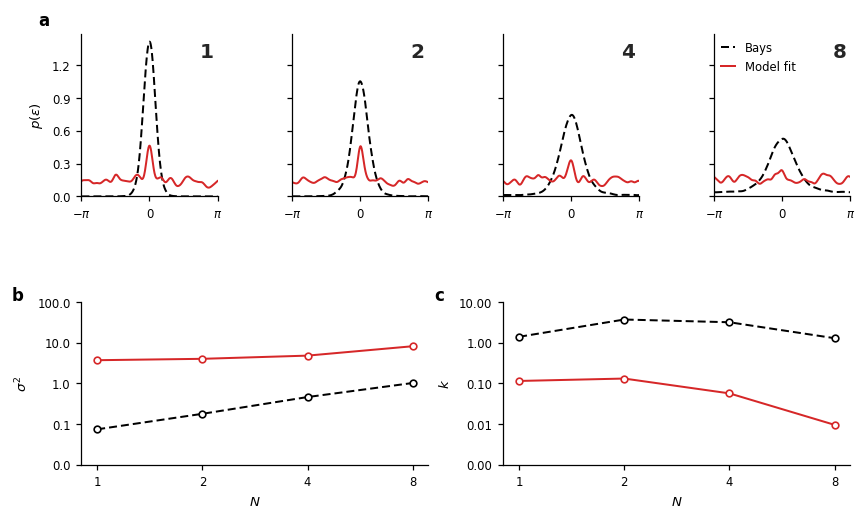

Plotting per-CV figure for CV = 10.0


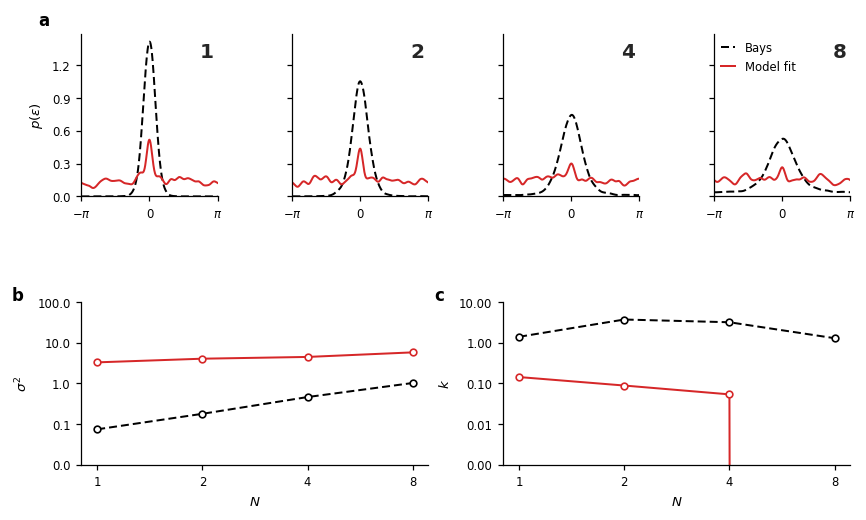

In [40]:
# === Part 3 — Style, helpers, and per-CV detail figures ===
# Cosmetic edits (panels, KDE smoothing, shared log ranges and all variable
# names unchanged):
#   * Title removed (caption carries the CV distinguisher).
#   * Panel-a epsilon x-label removed (caption explains the axis).
#   * Set-size label is a bare bold number in each panel-a top-right corner.
#   * Log y-ticks on panels b and c capped (~4 decades).
NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference
KDE_YTICKS     = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _auto_log_y(ax, lo, hi, numticks=4):
    """Decade major ticks across [lo, hi] from the sweep-wide data extent.

    numticks caps how many decade ticks appear so the axis stays clean.
    """
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=numticks))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def plot_cv_fit(cv, result):
    fitted_errors = result['fitted_errors']

    with mpl.rc_context(NATURE_STYLE):
        fig = plt.figure(figsize=(7.2, 4.6))
        gs = gridspec.GridSpec(
            2, len(SET_SIZES),
            hspace=0.65, wspace=0.55,
            left=0.08, right=0.97, bottom=0.12, top=0.90,
        )

        # (Title removed.)

        kdes_data = {N: vonmises_kde(bays_errs[N],     theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}
        kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}

        peak = max(max(k.max() for k in kdes_data.values()),
                   max(k.max() for k in kdes_fit.values()))
        kde_ymax = peak * 1.05
        kde_yticks = _pick_kde_yticks(kde_ymax)

        # ---- Row 1: KDE overlays ----
        i_legend = len(SET_SIZES) - 1            # legend lives on the last (N=8) panel
        for i, N in enumerate(SET_SIZES):
            ax = fig.add_subplot(gs[0, i])
            ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                    linestyle=BAYS_LINESTYLE, label='Bays' if i == i_legend else None)
            ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                    label='Model fit' if i == i_legend else None)
            ax.set_xlim(-np.pi, np.pi)
            ax.set_xticks([-np.pi, 0, np.pi])
            ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
            ax.set_yticks(kde_yticks)
            ax.set_ylim(0, kde_ymax)
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())
            # epsilon x-label removed; the caption describes the axis.

            # Bare set-size number, larger, tucked into the top-right corner.
            ax.text(0.97, 0.95, f'{N}', transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='top', ha='right',
                    color='0.15')

            if i == 0:
                ax.set_ylabel(r'$p(\varepsilon)$')
                ax.text(-0.32, 1.14, 'a', transform=ax.transAxes,
                        fontsize=10, fontweight='bold', va='top')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            if i == i_legend:
                # N=8 panel is broad and flat, so upper-left is clear of the curve.
                ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                          borderaxespad=0.2)
            _style_axes(ax)

        # ---- Row 2: variance and kurtosis (shared sweep-wide log range) ----
        # Reuse the moments computed once in Part 2 (stored on sweep_results);
        # fall back to computing them if this cell is run on its own.
        moments = result.get('moments')
        if moments is None:
            moments = {N: circular_moments(fitted_errors[N]) for N in SET_SIZES}
        var_fit  = np.array([moments[N]['variance'] for N in SET_SIZES])
        kurt_fit = np.array([moments[N]['kurtosis'] for N in SET_SIZES])

        ax_var = fig.add_subplot(gs[1, :2])
        ax_var.plot(SET_SIZES, var_bays_arr, marker='o', color=BAYS_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_var.set_yscale('log')
        _setsize_log_axis(ax_var, SET_SIZES)
        _auto_log_y(ax_var, VAR_LO, VAR_HI, numticks=4)
        ax_var.set_xlabel(r'$N$')
        ax_var.set_ylabel(r'$\sigma^2$')
        ax_var.text(-0.20, 1.10, 'b', transform=ax_var.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_var)

        ax_kurt = fig.add_subplot(gs[1, 2:])
        ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o', color=BAYS_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_kurt.plot(SET_SIZES, kurt_fit, marker='o', color=GP_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_kurt.set_yscale('log')
        _setsize_log_axis(ax_kurt, SET_SIZES)
        _auto_log_y(ax_kurt, KURT_LO, KURT_HI, numticks=4)
        ax_kurt.set_xlabel(r'$N$')
        ax_kurt.set_ylabel(r'$k$')
        ax_kurt.text(-0.20, 1.10, 'c', transform=ax_kurt.transAxes,
                     fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_kurt)

        cv_tag = str(cv).replace('.', 'p')
        stem = f'cv_sweep_{SWEEP_TAG}_cv{cv_tag}'
        png_path = os.path.join(SWEEP_OUTPUT_DIR, f'{stem}.png')
        pdf_path = os.path.join(SWEEP_OUTPUT_DIR, f'{stem}.pdf')
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        plt.show()


for cv in CV_VALUES:
    print(f'Plotting per-CV figure for CV = {cv}')
    plot_cv_fit(cv, sweep_results[cv])

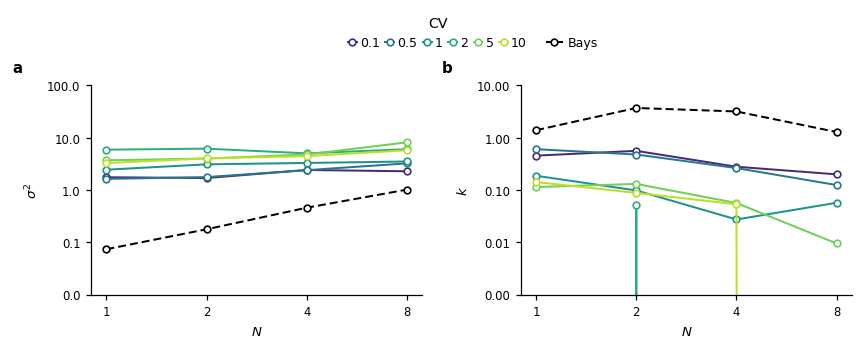


All figures saved to: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/experiment_2/20260803/gamma_10_gp/201034


In [47]:
# === Part 4 — Summary figure: variance & kurtosis vs N, all CVs overlaid ===
# Improvements:
#   * Title removed.
#   * Panel letters are now a and b (were b and c).
#   * CV shown as a compact titled legend of values (left); Bays key sits to
#     its right — both as one adjacent unit, lifted into a thin top strip.
#   * CV gradient uses a truncated-viridis (blue→green→yellow) map, not red;
#     Bays stays solid black.
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap

# CV -> colour via a sequential map (truncated viridis: skips the pale-yellow
# and darkest ends so every CV line stays legible on white). CV is log-spaced,
# so the colour assignment uses a log norm.
_base   = plt.get_cmap('viridis')
CV_CMAP = LinearSegmentedColormap.from_list('cv_seq', _base(np.linspace(0.12, 0.90, 256)))
_cv_arr = np.array([float(cv) for cv in CV_VALUES], dtype=float)
_vmin, _vmax = _cv_arr.min(), _cv_arr.max()
if _vmin == _vmax:                       # single-CV guard (LogNorm needs vmin<vmax)
    _vmin, _vmax = _vmin * 0.9, _vmax * 1.1
_cv_norm  = LogNorm(vmin=_vmin, vmax=_vmax)
cv_colors = [CV_CMAP(_cv_norm(cv)) for cv in _cv_arr]

with mpl.rc_context(NATURE_STYLE):
    fig = plt.figure(figsize=(7.2, 2.6))
    # Panels fill the height; keys live in a thin strip just above them.
    gs = gridspec.GridSpec(
        1, 2,
        wspace=0.30,
        left=0.09, right=0.97, bottom=0.17, top=0.84,
    )

    # --- Variance panel (a) ---
    ax_var = fig.add_subplot(gs[0, 0])
    ax_var.plot(SET_SIZES, var_bays_arr, marker='o',
                color=BAYS_COLOR, lw=1.2, ms=4, mfc='white', mew=1.0,
                linestyle=BAYS_LINESTYLE, zorder=10)
    for i, cv in enumerate(CV_VALUES):
        v = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['variance']
                      for N in SET_SIZES])
        ax_var.plot(SET_SIZES, v, marker='o',
                    color=cv_colors[i],
                    lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, VAR_LO, VAR_HI)
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.text(-0.24, 1.12, 'a', transform=ax_var.transAxes,
                fontsize=9, fontweight='bold', va='top')
    _style_axes(ax_var)

    # --- Kurtosis panel (b) ---
    ax_kurt = fig.add_subplot(gs[0, 1])
    ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o',
                 color=BAYS_COLOR, lw=1.2, ms=4, mfc='white', mew=1.0,
                 linestyle=BAYS_LINESTYLE, zorder=10)
    for i, cv in enumerate(CV_VALUES):
        k = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['kurtosis']
                      for N in SET_SIZES])
        ax_kurt.plot(SET_SIZES, k, marker='o',
                     color=cv_colors[i],
                     lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_kurt.set_yscale('log')
    _setsize_log_axis(ax_kurt, SET_SIZES)
    _auto_log_y(ax_kurt, KURT_LO, KURT_HI)
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.24, 1.12, 'b', transform=ax_kurt.transAxes,
                 fontsize=9, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    # --- Keys, side by side and lifted: CV value block (left) + Bays (right) ---
    # Anchored to a shared x (CV lower-right, Bays lower-left) so they abut.
    _leg_x, _leg_y = 0.60, 0.94
    cv_handles = [mpl.lines.Line2D([], [], color=cv_colors[i], lw=1.2, marker='o',
                                   ms=4, mfc='white', mew=1.0, linestyle='-',
                                   label=f'{cv:g}')
                  for i, cv in enumerate(CV_VALUES)]
    fig.legend(handles=cv_handles, loc='lower right',
               bbox_to_anchor=(_leg_x, _leg_y), ncol=len(CV_VALUES),
               title='CV', fontsize=7.5, title_fontsize=8.5, frameon=False,
               columnspacing=0.45, handlelength=0.7, handletextpad=0.25,
               borderaxespad=0.0)

    bays_handle = mpl.lines.Line2D([], [], color=BAYS_COLOR, lw=1.2,
                                   marker='o', ms=4, mfc='white', mew=1.0,
                                   linestyle=BAYS_LINESTYLE, label='Bays')
    fig.legend(handles=[bays_handle], loc='lower left',
               bbox_to_anchor=(_leg_x + 0.01, _leg_y), frameon=False, fontsize=7.5,
               handlelength=1.4, handletextpad=0.35, borderaxespad=0.0)

    summary_stem = f'cv_sweep_{SWEEP_TAG}_variance_kurtosis'
    summary_png  = os.path.join(SWEEP_OUTPUT_DIR, f'{summary_stem}.png')
    summary_pdf  = os.path.join(SWEEP_OUTPUT_DIR, f'{summary_stem}.pdf')
    fig.savefig(summary_png, dpi=300, bbox_inches='tight')
    fig.savefig(summary_pdf, bbox_inches='tight')
    plt.show()

print(f'\nAll figures saved to: {SWEEP_OUTPUT_DIR}')